In [6]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [47]:
df = pd.read_excel(r'E:/Artificial intelligence/4.PowerBI/Power BI Data Sources/Transport.xlsx')

In [8]:
df.head()

,TripID,ShipperID,CategoryID,Customer,ShipDate,OriginCity,OriginState,ShipDays,DestinationCity,DestinationState,DeliveryDate,TotalMiles,LoadedMiles,ShippingCost,Revenue,Capacity,TripType,CheckPoints
0,10001,1,5,Reddoit,2016-07-08,Grand Rapids,MI,3,Toledo,OH,2016-07-09,955,687,2232,2910,99,Domestic,9
1,10002,2,7,Plustax,2016-05-21,Milwaukee,WI,2,Springfield,IL,2016-05-23,317,317,646,1199,62,Domestic,8
2,10003,1,5,bamity,2016-08-29,Springfield,IL,1,Skokie,IL,2016-08-30,1026,780,-97,645,70,Domestic,2
3,10004,1,4,Quotelane,2016-08-25,Chicago,IL,4,Rockford,IL,2016-08-29,536,536,7276,5778,61,Domestic,10
4,10005,1,5,Viatom,2016-05-20,Indianapolis,IN,1,Northbrook,IL,2016-05-21,450,362,6807,7571,77,Domestic,4


In [10]:
df.shape

(2000, 18)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   TripID            2000 non-null   int64         
 1   ShipperID         2000 non-null   int64         
 2   CategoryID        2000 non-null   int64         
 3   Customer          2000 non-null   object        
 4   ShipDate          2000 non-null   datetime64[ns]
 5   OriginCity        2000 non-null   object        
 6   OriginState       2000 non-null   object        
 7   ShipDays          2000 non-null   int64         
 8   DestinationCity   2000 non-null   object        
 9   DestinationState  2000 non-null   object        
 10  DeliveryDate      1900 non-null   datetime64[ns]
 11  TotalMiles        2000 non-null   int64         
 12  LoadedMiles       2000 non-null   int64         
 13  ShippingCost      2000 non-null   int64         
 14  Revenue           2000 n

In [12]:
df.isna().sum()

TripID                0
ShipperID             0
CategoryID            0
Customer              0
ShipDate              0
OriginCity            0
OriginState           0
ShipDays              0
DestinationCity       0
DestinationState      0
DeliveryDate        100
TotalMiles            0
LoadedMiles           0
ShippingCost          0
Revenue               0
Capacity              0
TripType              0
CheckPoints           0
dtype: int64

In [18]:
(df.DeliveryDate == None).sum()

0

In [21]:
df[df.DeliveryDate.isna()].head()

,TripID,ShipperID,CategoryID,Customer,ShipDate,OriginCity,OriginState,ShipDays,DestinationCity,DestinationState,DeliveryDate,TotalMiles,LoadedMiles,ShippingCost,Revenue,Capacity,TripType,CheckPoints
13,10014,2,8,Subdrill,2016-03-17,Rockford,IL,10,Green Bay,WI,NaT,1175,361,763,1477,50,International,10
33,10034,2,8,Planethouse,2016-07-23,Monon,IN,9,Lansing,MI,NaT,1012,641,8065,8603,81,International,2
53,10054,1,4,dripkix,2016-01-21,Northbrook,IL,5,Naperville,IL,NaT,1008,778,5397,3284,71,International,4
73,10074,2,4,Kincorporation,2016-01-28,Milwaukee,WI,7,Springfield,IL,NaT,239,239,2315,581,58,International,6
93,10094,1,5,Pluslam,2016-08-29,Skokie,IL,9,Chicago,IL,NaT,771,601,1954,2742,87,International,8


# Revenue Vs Miles by Shipping State 

In [163]:
destinationRevenue = df.groupby("DestinationState").agg({"Revenue":"sum", "TotalMiles":"sum"}).reset_index()
destinationRevenue

,DestinationState,Revenue,TotalMiles
0,IA,396535,53417
1,IL,2971250,476289
2,IN,1055695,174464
3,MI,1882710,284027
4,OH,1071642,165372
5,WI,1362203,241468


Text(0.5, 1.0, 'Revenue Vs Miles by Shipping State')

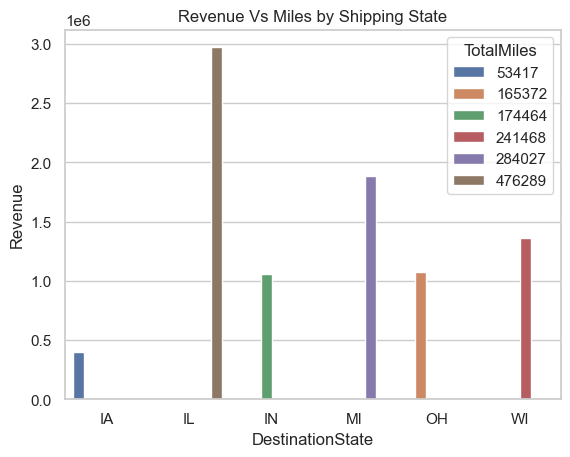

In [166]:
sns.barplot(data=destinationRevenue, x="DestinationState", y="Revenue", hue="TotalMiles")
plt.title("Revenue Vs Miles by Shipping State")

In [ ]:
# The most of revenue coming in IL and MI

# Revenue Vs Miles by Shipping City 

In [167]:
destinationRevenueCity = df.groupby("DestinationCity").agg({"Revenue":"sum", "TotalMiles":"sum"}).reset_index()

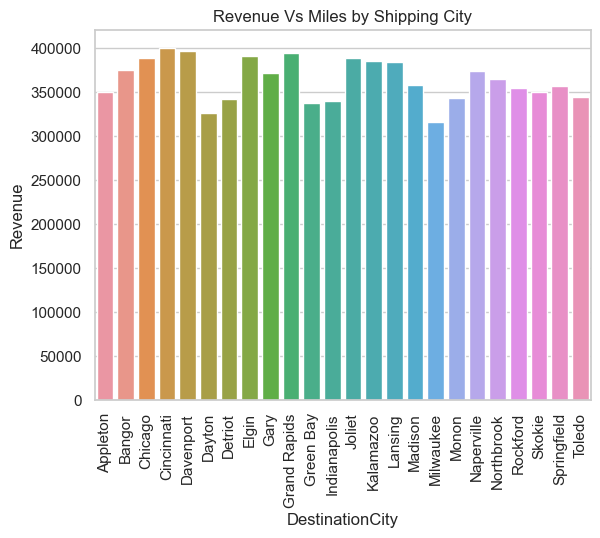

In [88]:
sns.barplot(data = destinationRevenueCity, x = "DestinationCity", y = "Revenue")
plt.xticks(rotation = 90)
plt.title("Revenue Vs Miles by Shipping City")
plt.show()

# Total Trips Vs Trips

In [110]:
totalTrips = df.groupby("TripType").agg({"ShipperID":"count"}).rename(columns={"ShipperID":"Total Trips"}).reset_index()

In [111]:
totalTrips.head()

,TripType,Total Trips
0,Domestic,1200
1,Intercom,100
2,International,700


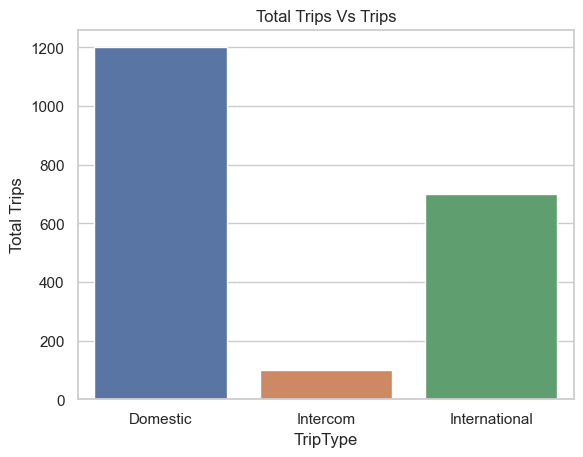

In [112]:
sns.barplot(data = totalTrips, x = "TripType", y = "Total Trips")
plt.title("Total Trips Vs Trips")
plt.show()

# % of Trips by Shipping State 

In [142]:
totalTripState = df.groupby(["DestinationState"])["ShipperID"].count()

In [143]:
percentageTotalTripByState = totalTripState / totalTripState.sum() * 100 

In [150]:
percentageTotalTripByState = pd.DataFrame(percentageTotalTripByState).reset_index().rename(columns={"ShipperID":"% of Trips"})

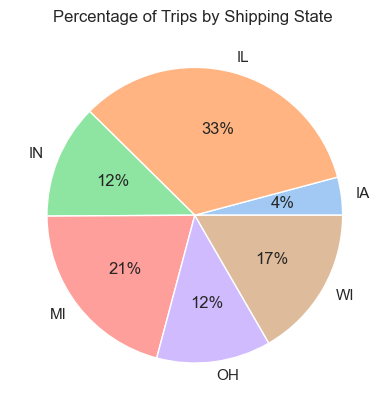

In [162]:
colors = sns.color_palette('pastel')
plt.pie(data = percentageTotalTripByState, labels = percentageTotalTripByState.DestinationState, colors = colors, x = "% of Trips", autopct='%.0f%%')
plt.title("Percentage of Trips by Shipping State ")
plt.show()

In [ ]:
# Revenue Miles vs Total Miles

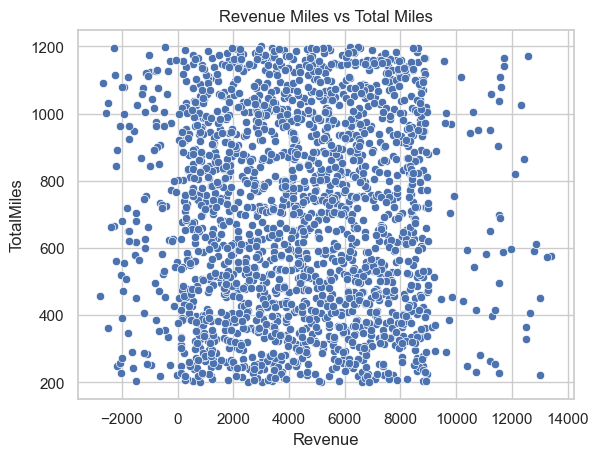

In [172]:
sns.scatterplot(data = df, x = "Revenue", y = "TotalMiles")
plt.title("Revenue Miles vs Total Miles")
plt.show()